Filename: m101.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     125   (530, 530)   int16   
  1  Photometric CALTABLE    1 BinTableHDU     39   16R x 4C   [1D, 1D, 1D, 1J]   
['SIMPLE', 'BITPIX', 'NAXIS', 'NAXIS1', 'NAXIS2']
BITPIX = 16
Shape: (530, 530)
dtype: >i2
min: 1507
max: 15752
mean: 4795.924268422927
std: 1848.2526085366376
median: 4102.0
mode: 3551


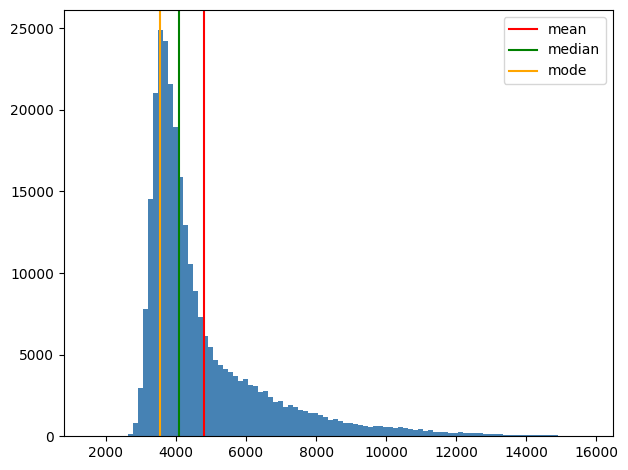

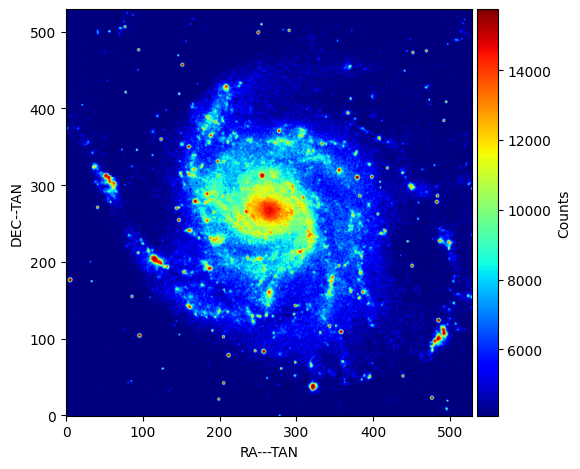

Filename: m101_float.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     125   (530, 530)   float64   
BUNIT = Counts
dtype = >f8


In [2]:
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from mpl_toolkits.axes_grid1 import make_axes_locatable
import warnings

hdul = fits.open("m101.fits")
hdul.info()

hdr = hdul[0].header
keys = list(hdr.keys())
print(keys[:5])
print("BITPIX =", hdr["BITPIX"])

dat = hdul[0].data
print("Shape:", dat.shape)
print("dtype:", dat.dtype)

flat = dat.flatten()
print("min:", np.min(flat))
print("max:", np.max(flat))
print("mean:", np.mean(flat))
print("std:", np.std(flat))
print("median:", np.median(flat))
modeval = stats.mode(flat, keepdims=True).mode[0]
print("mode:", modeval)

fig, ax = plt.subplots()
ax.hist(flat, bins=100, color="steelblue")
ax.axvline(np.mean(flat), color="red", label="mean")
ax.axvline(np.median(flat), color="green", label="median")
ax.axvline(modeval, color="orange", label="mode")
ax.legend()
plt.tight_layout()
plt.show()

datf = np.asarray(dat, dtype=float)
med = np.median(datf)
 
fig, ax = plt.subplots()
im = ax.imshow(datf, vmin=med, origin="lower", cmap="jet")
ax.set_xlabel(hdr["CTYPE1"])
ax.set_ylabel(hdr["CTYPE2"])
 
div = make_axes_locatable(ax)
cax = div.append_axes("right", size="5%", pad=0.05)
cbar = fig.colorbar(im, cax=cax)
cbar.set_label(hdr.get("BUNIT", "Counts"))
 
plt.tight_layout()
plt.show()

hdr['BUNIT'] = 'Counts'

newhdu = fits.PrimaryHDU(data=datf, header=hdr)
newhdul = fits.HDUList([newhdu])

with warnings.catch_warnings():
    warnings.simplefilter('ignore', fits.verify.VerifyWarning)
    newhdul.writeto('m101_float.fits', overwrite=True, output_verify='silentfix')

with fits.open('m101_float.fits') as check:
    check.info()
    print(f"BUNIT = {check[0].header['BUNIT']}")
    print(f"dtype = {check[0].data.dtype}")

hdul.close()

530


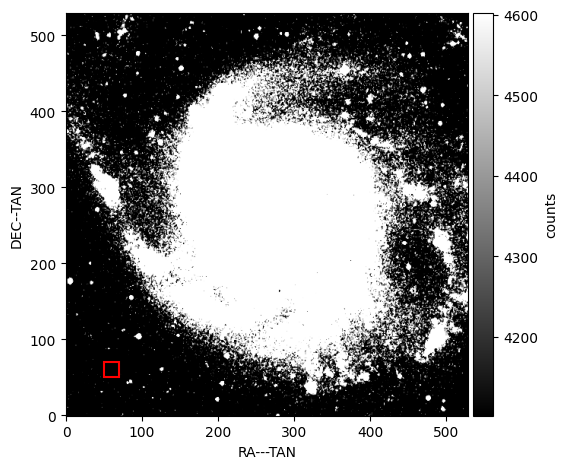

pixels: 400
mean: 3445.9275
std: 254.94747938300938
rms: 3455.345793477116


In [26]:
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

hdul = fits.open("m101.fits")
hdr = hdul[0].header
dat = np.asarray(hdul[0].data, dtype=float)
hdul.close()

sky = dat[50:70, 50:70]

fig, ax = plt.subplots()
med = np.median(dat)
im = ax.imshow(dat, origin="lower", cmap="gray", vmin=med, vmax=med+500)
rect = plt.Rectangle((50, 50), 20, 20, edgecolor="red", facecolor="none", lw=1.5)
ax.add_patch(rect)
ax.set_xlabel(hdr.get("CTYPE1", "x"))
ax.set_ylabel(hdr.get("CTYPE2", "y"))
div = make_axes_locatable(ax)
cax = div.append_axes("right", size="5%", pad=0.05)
fig.colorbar(im, cax=cax).set_label("counts")
plt.tight_layout()
plt.show()

flat = sky.flatten()
n = len(flat)
mean = np.mean(flat)
std = np.std(flat)
rms = np.sqrt(np.mean(flat**2))

print(f"pixels: {n}")
print(f"mean: {mean}")
print(f"std: {std}")
print(f"rms: {rms}")

In [27]:
from astropy.io import fits
import numpy as np

d0 = fits.open("noisemap0.fits")[0].data
d1 = fits.open("noisemap1.fits")[0].data
d2 = fits.open("noisemap2.fits")[0].data

print("std d0:", np.std(d0))
print("std d1:", np.std(d1))
print("std d2:", np.std(d2))

stack = np.stack([d0, d1, d2], axis=0)
print("stack shape:", stack.shape)

mean = np.mean(stack, axis=0)
print("mean image shape:", mean.shape)

std_mean = np.std(mean)
print("std of mean image:", std_mean)

sig = (1/3) * np.sqrt(np.std(d0)**2 + np.std(d1)**2 + np.std(d2)**2)
print("theoretical std:", sig)

std d0: 9.98401556679484
std d1: 10.003955116338458
std d2: 9.995349488722516
stack shape: (3, 893, 891)
mean image shape: (893, 891)
std of mean image: 5.773191380233297
theoretical std: 5.770294583366139


In [9]:
from astropy.io import fits
from astropy.table import Table
import numpy as np

hdul = fits.open("APOGEE_stars.fits")
data = hdul[1].data
hdul.close()

t = Table(data)

sf   = np.array(t["STARFLAG"])
af   = np.array(t["ASPCAPFLAG"])
snr  = np.array(t["SNR"])
plx  = np.array(t["GAIAEDR3_PARALLAX"])
eplx = np.array(t["GAIAEDR3_PARALLAX_ERROR"])
g    = np.array(t["GAIAEDR3_PHOT_G_MEAN_MAG"])
bp   = np.array(t["GAIAEDR3_PHOT_BP_MEAN_MAG"])
rp   = np.array(t["GAIAEDR3_PHOT_RP_MEAN_MAG"])

flag = ((sf == 0)&(af == 0)&(snr > 10)&(plx > 0)&(plx / eplx > 5)&np.isfinite(g)&np.isfinite(bp)&np.isfinite(rp)).astype(int)

t["DATAFLAG"] = flag

absmag = np.full(len(t), -1.0)

good = flag == 1
dist = 1000.0 / plx[good]
absmag[good] = g[good] - 5.0 * np.log10(dist / 10.0)

t["ABS_MAG_G"] = absmag

t.write("APOGEE_update.fits", overwrite=True)

with fits.open("APOGEE_update.fits") as chk:
    chk.info()
    print("Columns:", chk[1].columns.names)

Filename: APOGEE_update.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1                1 BinTableHDU     28   733901R x 10C   [E, E, E, E, E, K, K, E, K, D]   
Columns: ['GAIAEDR3_PARALLAX', 'GAIAEDR3_PARALLAX_ERROR', 'GAIAEDR3_PHOT_G_MEAN_MAG', 'GAIAEDR3_PHOT_BP_MEAN_MAG', 'GAIAEDR3_PHOT_RP_MEAN_MAG', 'ASPCAPFLAG', 'STARFLAG', 'SNR', 'DATAFLAG', 'ABS_MAG_G']
[-1. -1. -1. ... -1. -1. -1.]


max flux: 42489404.0
source_id                  1.741834e+07
ra                         2.358429e+02
ra_error                   5.007553e-03
dec                        1.171101e+01
dec_error                  4.450002e-03
phot_g_mean_flux           4.248940e+07
phot_g_mean_flux_error     5.649703e+03
phot_g_mean_mag            6.617699e+00
phot_bp_mean_flux          1.572251e+07
phot_bp_mean_flux_error    9.947167e+03
phot_bp_mean_mag           7.360095e+00
phot_rp_mean_flux          3.165592e+07
phot_rp_mean_flux_error    2.005618e+04
phot_rp_mean_mag           6.010764e+00
a_g_val                    0.000000e+00
e_bp_min_rp_val            0.000000e+00
Name: 64, dtype: float64


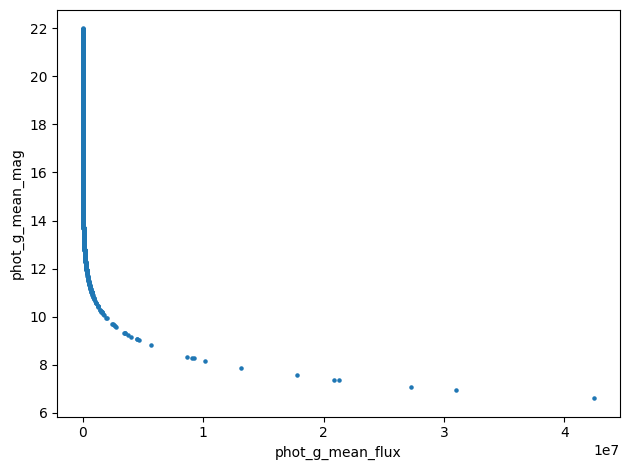

mean F0: 18852117942.14138
std  F0: 6773.923727355158


In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("gaiaTestData.csv")

idx = df["phot_g_mean_flux"].idxmax()
print("max flux:", df["phot_g_mean_flux"].max())
print(df.loc[idx])

df = df.sort_values("phot_g_mean_flux")

F = df["phot_g_mean_flux"].values
m = df["phot_g_mean_mag"].values

fig, ax = plt.subplots()
ax.scatter(F, m, s=5)
ax.set_xlabel("phot_g_mean_flux")
ax.set_ylabel("phot_g_mean_mag")
plt.tight_layout()
plt.show()

F0 = F / 10**(-m / 2.5)
print("mean F0:", np.mean(F0))
print("std  F0:", np.std(F0))

In [30]:
from astroquery.gaia import Gaia
import pandas as pd

query = """
SELECT TOP 50
    source_id, ra, dec, parallax, parallax_error,
    phot_g_mean_mag, phot_bp_mean_mag, phot_rp_mean_mag
FROM gaiadr3.gaia_source
WHERE parallax / parallax_error > 5
  AND phot_g_mean_mag IS NOT NULL
  AND phot_bp_mean_mag IS NOT NULL
  AND phot_rp_mean_mag IS NOT NULL
"""

job = Gaia.launch_job(query)
result = job.get_results()

df = result.to_pandas()
print(df)

result.write("astroquery_gaia.fits", overwrite=True)

          SOURCE_ID         ra       dec   parallax  parallax_error  \
0      549755818112  45.048282  0.048254   1.583477        0.034425   
1     3508989119232  45.055954  0.146112   1.169073        0.029833   
2     4810363437952  44.910297  0.114756   1.767197        0.235550   
3     6944962925824  44.975822  0.187814   0.990405        0.019034   
4     8418136080384  45.037408  0.261614   1.810867        0.139456   
5     8834748568832  45.184044  0.163180   2.338353        0.084994   
6    13125420068480  45.258327  0.354920   1.543873        0.146117   
7    15633681152896  45.201384  0.342090   1.887225        0.356721   
8    16973710962944  45.118527  0.392875   0.602777        0.088843   
9    19211389524736  44.781045  0.257446   0.369344        0.041127   
10   19275813400064  44.839607  0.241480   1.240225        0.180970   
11   19619410717184  44.800798  0.263863   1.461488        0.273750   
12   24434069751936  44.838398  0.344779   1.126924        0.019086   
13   2

In [32]:
class Fibonacci:
    """Class for calculating Fibonacci sequence"""

    def nth(self, n):
        a, b = 0, 1
        for i in range(n):
            a, b = b, a + b
        return a

    def divisible(self, n, m):
        result = []
        a, b = 0, 1
        for j in range(n):
            if a % m == 0:
                result.append(a)
            a, b = b, a + b
        return result

fib = Fibonacci()

print("100th Fibonacci number:", fib.nth(100))
print("Fibonacci numbers below N=100 divisible by M=7:", fib.divisible(100, 7))

100th Fibonacci number: 354224848179261915075
Fibonacci numbers below N=100 divisible by M=7: [0, 21, 987, 46368, 2178309, 102334155, 4807526976, 225851433717, 10610209857723, 498454011879264, 23416728348467685, 1100087778366101931, 51680708854858323072]
